In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.descritiva import  (
    matriz_migracao,
    cria_base_decil_wide
)

from utilities.functions import (
    summary,
    gerar_resumo_decis,
    resumo_coorte_ativa,
    process_orders_pandas

)
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [2]:
df_pub_u = pd.read_parquet(BASE_PATH / "silver" / "df_publico_orders.parquet")
df_pub_u
#df_pub_u=process_orders_pandas(df_pub_u)

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform
0,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,e80a8d7a13b52ca9ccf247ca3396f1018be41a5b014d79...,2019-01-11T14:07:48.000Z,c9a236fc0b0255433d0852dc90ef8b9949f3a3ab67e553...,10.0,ANDROID
1,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-05T13:38:28.000Z,db3b910b374ce240d551b829b297b9547f4e2feee9fd78...,12.0,ANDROID
2,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-13T13:50:06.000Z,a20903719abdaae9f6639681845f95963de83e0047ff13...,13.0,ANDROID
3,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-26T13:15:53.000Z,90652cc196fbfa352b1d4d61b18b5babf39fad949c7ccc...,13.0,ANDROID
4,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-15T13:48:33.000Z,9091a0ead77e2ed0d5ed9ce6787631386bd120036ff5b7...,13.0,ANDROID
...,...,...,...,...,...,...,...,...,...,...
3661045,b204e707910c9d439f8a144c5799dfc0a34aa116c712c6...,target,True,2018-04-06T04:00:47.944Z,SP,393f8e1da699388197c086515ac1c62d5594e271ecb638...,2019-01-23T00:00:20.000Z,94d104c0288aff32bc9386ac1f0bd542d748a266e74f00...,49.9,DESKTOP
3661046,0eeea5f0ef562133be19c93f3c69ae5ef6bac970636605...,target,True,2018-01-04T21:55:14.445Z,CE,264c07994a51e2686a70d8e8fefc725adb877fa9868879...,2019-01-29T22:58:24.000Z,56e126092ffb1210b8b8751f497273bd05ac43c598f48f...,51.8,ANDROID
3661047,2c58fb2b18f606a19156d4e67d727109660701a112c0af...,target,True,2018-01-05T22:05:31.168Z,PR,8643e3a9b252c18e42001bd2d7f7057f02b872d54a3b41...,2019-01-02T22:46:11.000Z,5348ec79a4d7587b2fd240ffae789278d3be3e9860d7a5...,47.4,ANDROID
3661048,5d7242c38e0d2958810ca41c82fd734d2c80d11d03d2f7...,control,True,2018-04-06T03:48:15.956Z,RJ,3b977d719333809e045e73c955ad6092b9dde8a255cd71...,2019-01-09T00:07:57.000Z,8e0b1a21bca2ea502e651274d35d605562d712297ab3c9...,38.0,ANDROID


In [3]:
#df_pub_u[df_pub_u['customer_id']=='c97d3dd3fe60ec47f11e46d05614ded381884a1e5c16a6bf4ce3f47a61d77081']

In [4]:
df_pub_u=process_orders_pandas(df_pub_u)


In [5]:
df_pub_u = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_u['pedidos_sum'] = np.where(
        df_pub_u['num_pedidos_mes'] > 10, 11,
        df_pub_u['num_pedidos_mes'].astype(str)
    )
df_pub_u.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2


In [6]:
df_pub_u.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2


Sumarizacao na visao cliente - mes

In [7]:
summary(df_pub_u)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1360532,806156,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_target,1360532,2,target,758662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_created_month,1360532.0,NaN,NaN,NaN,5.48217,5.405002,1.0,1.0,1.0,12.0,12.0
num_pedidos_mes,1360532.0,NaN,NaN,NaN,2.690896,3.246342,1.0,1.0,2.0,3.0,157.0
num_pedidos_hist,1360532.0,NaN,NaN,NaN,5.11179,6.023283,1.0,2.0,3.0,6.0,239.0
total_amount_mes,1360532.0,NaN,NaN,NaN,128.64053,257.078642,0.0,39.0,68.8,142.7,140338.9
ticket_medio,1360532.0,NaN,NaN,NaN,47.96733,94.513167,0.0,29.3,40.9,56.9,70169.45
pedidos_sum,1360532,11,1,678099,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Clientes mes x target

 Matriz de migracao - cliente

In [8]:
df_pub_u['is_target'].unique()

array(['control', 'target'], dtype=object)

In [9]:
matriz_migracao(df_pub_u,mes_0=12,mes_1=1)

,mes_12,mes_1,is_target,total_clientes
0,0,1,control,118956
1,0,1,target,132824
2,1,1,control,241457
3,1,1,target,312919


Dado o montante de clientes novos em janeiro a analise sera feita basead em cliente ambos os meses e cliente somente em janeiro

In [10]:
id_both_monht=df_pub_u[df_pub_u['order_created_month']==12]['customer_id'].unique()
publico_janeiro_dezembro = df_pub_u[df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)
publico_janeiro = df_pub_u[~df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)

In [11]:
#publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet", index=False)

Pedidos por mes - target

In [12]:
# Análise completa unificada
analise_completa = (
    publico_janeiro_dezembro.groupby(['is_target','order_created_month'])
    .agg(
        numero_de_pedidos_total=('num_pedidos_mes', 'sum'),
        total_amount=('total_amount_mes', 'sum'),
      #  customer_count=('customer_id', 'nunique')
    )
    .reset_index()
)

# Calculando percentuais para pedidos
analise_completa['pct_pedidos_mes'] = analise_completa.groupby('order_created_month')['numero_de_pedidos_total'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

# Calculando percentuais para valor total
analise_completa['pct_amount_mes'] = analise_completa.groupby('order_created_month')['total_amount'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

analise_completa


,is_target,order_created_month,numero_de_pedidos_total,total_amount,pct_pedidos_mes,pct_amount_mes
0,control,1,844890,40570468.27,41.03,41.09
1,control,12,514666,24631078.76,41.69,41.82
2,target,1,1214354,58175914.90,58.97,58.91
3,target,12,719794,34265292.99,58.31,58.18


Distruibuicao do total amount por mes

In [13]:
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])['total_amount_mes'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes

Média  Mediana  Mínimo     Máximo  \
order_created_month is_target                                       
1                   control    168.02    88.10     0.0  140338.90   
                    target     185.91   104.90     0.0    9813.87   
12                  control    102.01    59.88     0.0  140338.90   
                    target     109.50    65.50     0.0    7409.67   

                               Desvio_Padrão  
order_created_month is_target                 
1                   control           372.96  
                    target            252.94  
12                  control           314.40  
                    target            137.72

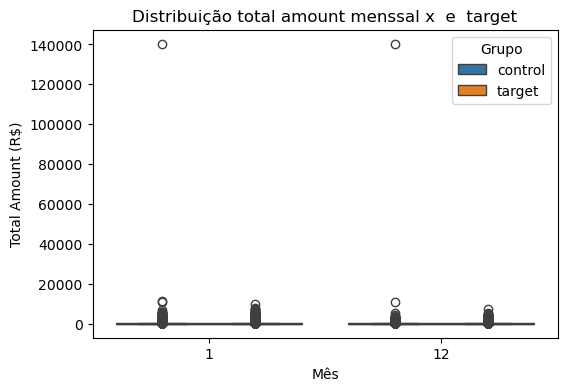

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=publico_janeiro_dezembro,
    y='total_amount_mes',
    x='order_created_month',  
    hue='is_target'          
)
plt.title('Distribuição total amount menssal x  e  target')
plt.ylabel('Total Amount (R$)')
plt.xlabel('Mês')
plt.legend(title='Grupo')
plt.show()

Observa-se grande numero de outliers, verificar a distribuicao removendo outliers.

Tukey’s Method

In [15]:
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==12]['total_amount_mes'].describe().round(2))
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==1]['total_amount_mes'].describe().round(2))



count    554376.00
mean        106.24
std         231.89
min           0.00
25%          37.10
50%          62.90
75%         122.40
max      140338.90
Name: total_amount_mes, dtype: float64
count    554376.00
mean        178.12
std         311.09
min           0.00
25%          47.90
50%          97.70
75%         209.00
max      140338.90
Name: total_amount_mes, dtype: float64


<Axes: >

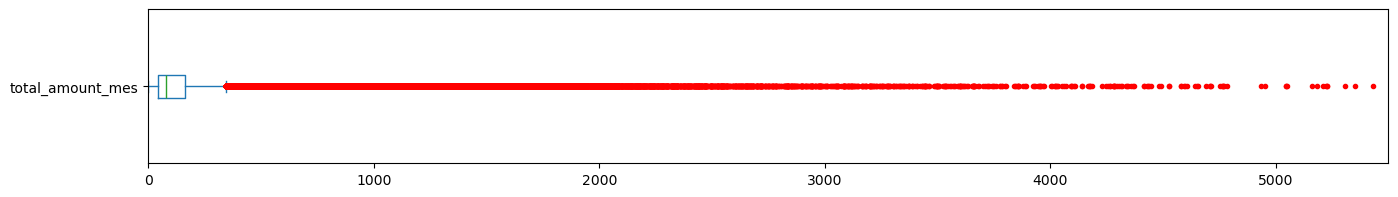

In [16]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
publico_janeiro_dezembro['total_amount_mes'].plot(kind='box', xlim=(0, 5500), vert=False, flierprops=red_square, figsize=(16,2))

In [17]:
p75=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],75)
p25=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],25)

In [18]:
distance = 1.5 * (p75 - p25)
lim_sup= p75+distance
lim_inf = p25-distance
print(lim_sup)


250.35625000000002


Marcacao de outliers - amount na base historica e griando uma base somente com outliers

In [19]:
publico_janeiro_dezembro['outlier'] = publico_janeiro_dezembro['total_amount_mes'] > lim_sup
df_out= publico_janeiro_dezembro[publico_janeiro_dezembro['total_amount_mes'] > lim_sup]

In [20]:
total_amount = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)

total_amount_out = df_out.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)
#total_amount_out
#total_amount

merged = (
    total_amount
    .merge(total_amount_out, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4)
    )
)
merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control         40570468.27             844890   
                    target          58175914.90            1214354   
12                  control         24631078.76             514666   
                    target          34265292.99             719794   

                               total_amount_out  total_pedidos_out  \
order_created_month is_target                                        
1                   control         23593507.89             421299   
                    target          35041697.09             629544   
12                  control          8402347.10             131568   
                    target          12250198.13             195118   

                               pct_amount_out  pct_pedidos_out  
order_created_month is_target                                   
1                   control            0.5815           0.4986  
                    target             0.6023           0.5184  
12                  control            0.3411           0.2556  
                    target             0.3575           0.2711

In [21]:
#from scipy.stats import zscore
#df['z'] = zscore(df['total_amount_out'])
#outliers = df[abs(df['z']) > 3]


Migracao based in marcacao de outlier

In [22]:
matriz_migracao(publico_janeiro_dezembro, 12, 1, group_by_extra='outlier')

,mes_12,mes_1,is_target,outlier,total_clientes
0,0,1,control,True,25980
1,0,1,target,True,38896
2,1,0,control,False,25980
3,1,0,target,False,38896
4,1,1,control,False,196564
5,1,1,control,True,18913
6,1,1,target,False,245997
7,1,1,target,True,28026


Entender quem sao esse clientes outliers

In [23]:
decil_dict = cria_base_decil_wide(publico_janeiro_dezembro, mes_0=12)

# 2) Aplicar
publico_janeiro_dezembro['decil'] = publico_janeiro_dezembro['total_amount_mes'].apply(
    lambda x: max([decil for decil, (min_val, max_val) in decil_dict.items() if x >= min_val])
)

In [24]:
clientes_mes = (
    publico_janeiro_dezembro.groupby(['order_created_month','decil'], dropna=False)
              ['customer_id']
              .nunique()
              .reset_index(name='numero_clientes_distintos')
)
clientes_mes

,order_created_month,decil,numero_clientes_distintos
0,1,1,36997
1,1,2,37572
2,1,3,37968
3,1,4,38818
4,1,5,41656
5,1,6,46052
6,1,7,52989
7,1,8,60606
8,1,9,75943
9,1,10,125775


In [25]:
def calcular_stats(group):
    media = group['total_amount_mes'].mean()
    std = group['total_amount_mes'].std()
    return pd.Series({
        'Total_Clientes': group['customer_id'].nunique(),
        'Total_Orders': group['num_pedidos_mes'].sum(),  # ou count() dependendo da sua estrutura
        'Média_Amount': media,
        'Mediana_Amount': group['total_amount_mes'].median(),
        'Mínimo_Amount': group['total_amount_mes'].min(),
        'Máximo_Amount': group['total_amount_mes'].max(),
        'Desvio_Padrão_Amount': std,
        'CV_Amount': (std / media * 100) if media != 0 else np.nan
    })

df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)
df_stats_mes.head()

/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_13115/3857564857.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)


Total_Clientes  Total_Orders  \
order_created_month is_target decil                                 
1                   control   1             18459.0       18814.0   
                              2             18592.0       19716.0   
                              3             18435.0       20841.0   
                              4             18191.0       22504.0   
                              5             19117.0       27208.0   

                                     Média_Amount  Mediana_Amount  \
order_created_month is_target decil                                 
1                   control   1             18.23           18.90   
                              2             28.74           28.90   
                              3             37.20           37.00   
                              4             46.11           46.00   
                              5             56.55           56.49   

                                     Mínimo_Amount  Máximo_Amount  \
order_created_month is_target decil                                 
1                   control   1                0.0          24.49   
                              2               24.5          32.99   
                              3               33.0          41.49   
                              4               41.5          50.79   
                              5               50.8          62.89   

                                     Desvio_Padrão_Amount  CV_Amount  
order_created_month is_target decil                                   
1                   control   1                      4.25      23.30  
                              2                      2.51       8.72  
                              3                      2.44       6.57  
                              4                      2.71       5.88  
                              5                      3.44       6.08

In [26]:
#publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet", index=False)

In [27]:
os.makedirs('../../Resultados', exist_ok=True)

df_stats_mes.to_csv('../../Resultados/decil_summary.csv', index=False)



In [28]:
publico_janeiro_dezembro.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2,False,7
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8,True,10
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2,False,8
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3,False,9
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2,False,6


Numero de pedidos em Janeiro e Dezembro para o quem esteve em ambos meses

In [29]:
# Análise por mês
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique'),
    total_amount_mes=('total_amount_mes', 'sum')
).round(2)

df_stats_mes['pct_mes'] = df_stats_mes.groupby('order_created_month')['total_clientes'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

# Análise geral
df_stats_hist = publico_janeiro_dezembro.groupby(['pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique'),
    total_amount=('total_amount_mes', 'sum')
).round(2)

# Criar coluna numérica para ordenação
df_stats_hist = df_stats_hist.reset_index()
df_stats_hist['pedidos_num'] = df_stats_hist['pedidos_sum'].replace('10+', 11).astype(int)
df_stats_hist = df_stats_hist.sort_values('pedidos_num', ascending=True).drop('pedidos_num', axis=1)
df_stats_hist = df_stats_hist.set_index('pedidos_sum')

# Cálculos de percentual
df_stats_hist['pct_total'] = (df_stats_hist['total_clientes'] / df_stats_hist['total_clientes'].sum() * 100).round(2)
df_stats_hist['Pedidos_Acumulados'] = df_stats_hist['total_clientes'].cumsum()
df_stats_hist['%_Acumulada'] = (df_stats_hist['Pedidos_Acumulados'] / df_stats_hist['total_clientes'].sum()) * 100

# DataFrames resetados
df_stats_hist_d = df_stats_hist.reset_index()
df_stats_mes_d = df_stats_mes.reset_index()

In [30]:
df_stats_hist_d

,pedidos_sum,total_clientes,total_amount,pct_total,Pedidos_Acumulados,%_Acumulada
0,1,300412,23753504.38,36.46,300412,36.459094
1,2,167956,21131032.40,20.38,468368,56.842846
2,3,105291,17678455.01,12.78,573659,69.621345
3,4,69756,14791255.47,8.47,643415,78.087188
4,5,47569,12240363.55,5.77,690984,83.860335
5,6,33525,10182860.05,4.07,724509,87.929051
6,7,23958,8330393.74,2.91,748467,90.836681
7,8,17791,7007986.06,2.16,766258,92.995861
8,9,13270,5843972.62,1.61,779528,94.606357
9,10,10047,4870479.16,1.22,789575,95.825698


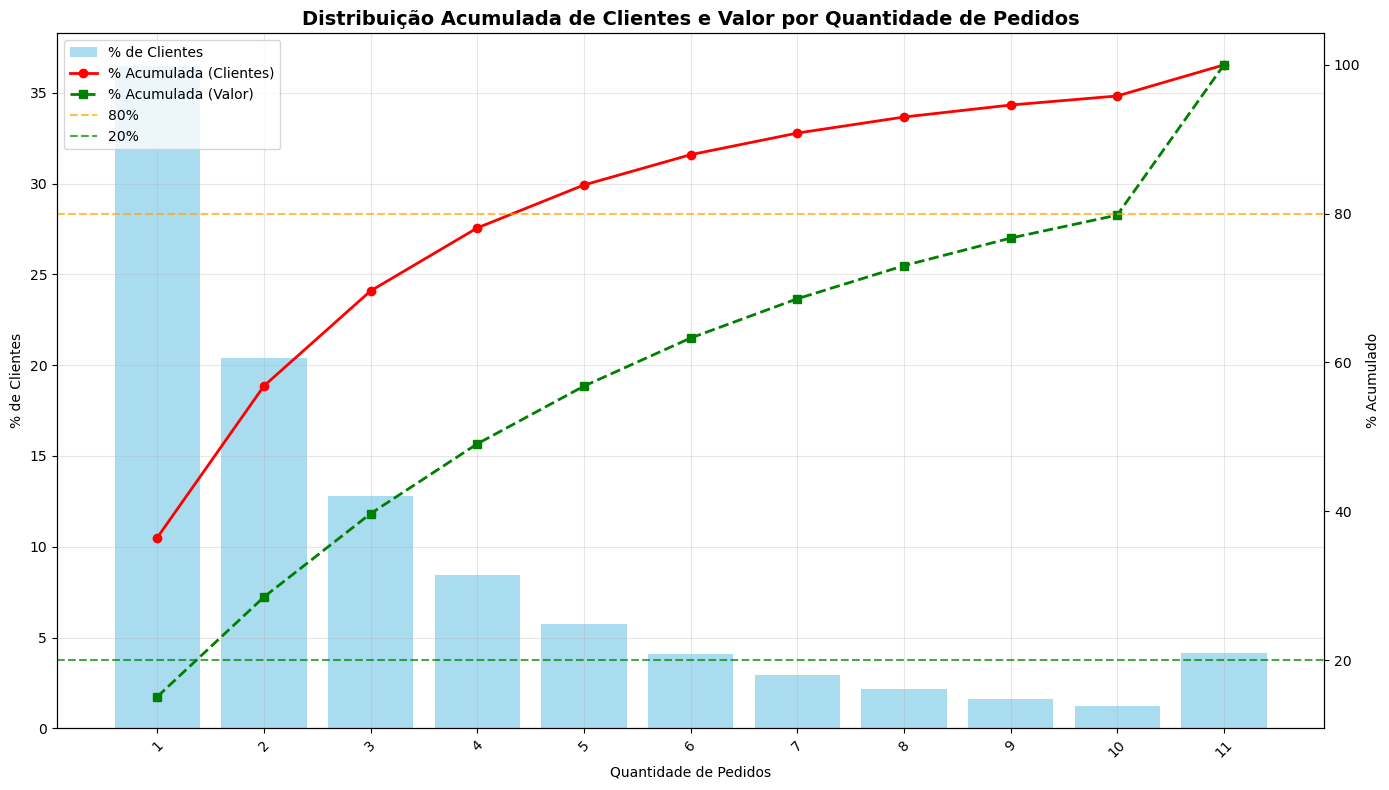

=== COMPARAÇÃO CLIENTES vs VALOR ===
Categorias com 80% dos clientes: ['1', '2', '3', '4']
Categorias com 80% do valor: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


In [31]:
import matplotlib.pyplot as plt

# Calcular percentuais do amount
df_stats_hist_d['pct_amount'] = (df_stats_hist_d['total_amount'] / df_stats_hist_d['total_amount'].sum() * 100).round(2)
df_stats_hist_d['amount_acumulado'] = df_stats_hist_d['pct_amount'].cumsum()

# Criar coluna numérica para ordenação (se não existir)
if 'pedidos_num' not in df_stats_hist_d.columns:
    df_stats_hist_d['pedidos_num'] = df_stats_hist_d['pedidos_sum'].replace('10+', 11).astype(int)

# Preparar dados ordenados
df_sorted = df_stats_hist_d.sort_values('pedidos_num')

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(14, 8))

# Barras - % de clientes por categoria
bars = ax1.bar(range(len(df_sorted)), df_sorted['pct_total'], 
               color='skyblue', alpha=0.7, label='% de Clientes')

# Linha - % acumulada de clientes
ax2 = ax1.twinx()
line1 = ax2.plot(range(len(df_sorted)), df_sorted['%_Acumulada'], 
                 color='red', marker='o', linewidth=2, label='% Acumulada (Clientes)')

# Linha - % acumulada do valor
line2 = ax2.plot(range(len(df_sorted)), df_sorted['amount_acumulado'], 
                 color='green', marker='s', linewidth=2, linestyle='--', 
                 label='% Acumulada (Valor)')

# Configurar eixo X
ax1.set_xticks(range(len(df_sorted)))
ax1.set_xticklabels(df_sorted['pedidos_sum'], rotation=45)

# Títulos e labels
plt.title('Distribuição Acumulada de Clientes e Valor por Quantidade de Pedidos', fontsize=14, fontweight='bold')
ax1.set_xlabel('Quantidade de Pedidos')
ax1.set_ylabel('% de Clientes')
ax2.set_ylabel('% Acumulado')

# Linhas de referência
ax2.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(y=20, color='green', linestyle='--', alpha=0.7, label='20%')

# Combinar todas as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar insights
print("=== COMPARAÇÃO CLIENTES vs VALOR ===")
categoria_80_clientes = df_sorted[df_sorted['%_Acumulada'] <= 80]['pedidos_sum'].tolist()
categoria_80_valor = df_sorted[df_sorted['amount_acumulado'] <= 80]['pedidos_sum'].tolist()

print(f"Categorias com 80% dos clientes: {categoria_80_clientes}")
print(f"Categorias com 80% do valor: {categoria_80_valor}")

In [32]:
publico_janeiro_dezembro['num_pedidos_mes'].unique()

array([  2,   8,   3,   1,  11,  23,   4,   7,   5,  10,   6,   9,  12,
        14,  31,  16,  13,  19,  15,  18,  22,  25,  17,  20,  29,  24,
        21,  41,  39,  35,  28,  30,  26,  27,  42,  37,  46,  32,  52,
        36,  38,  79,  69,  60,  34,  50,  33,  49,  68,  54,  40,  56,
        48,  51,  47,  43,  58,  44,  57,  87,  71,  80,  61,  63,  45,
        53,  72,  59,  64,  62,  81,  55,  67,  73,  92,  66, 105,  75,
        84,  86,  74,  82, 157,  65, 101,  85])

In [33]:
df_stats_mes

total_clientes  total_amount_mes  pct_mes
order_created_month pedidos_sum                                           
1                   11                    34395       26815987.26     6.20
                    1                    195166        9282452.04    35.20
                    10                     7742        3711870.82     1.40
                    2                    106593       10342216.05    19.23
                    3                     67767        9756996.35    12.22
                    4                     46341        8934690.64     8.36
                    5                     32575        7874521.82     5.88
                    6                     23456        6816634.78     4.23
                    7                     17248        5817965.13     3.11
                    8                     13125        5072541.81     2.37
                    9                      9968        4320506.47     1.80
12                  11                     7489        4996465.22     1.35
                    1                    300412       14471052.34    54.19
                    10                     2479        1158608.34     0.45
                    2                    111574       10788816.35    20.13
                    3                     55178        7921458.66     9.95
                    4                     30709        5856564.83     5.54
                    5                     18349        4365841.73     3.31
                    6                     11797        3366225.27     2.13
                    7                      7610        2512428.61     1.37
                    8                      5167        1935444.25     0.93
                    9                      3612        1523466.15     0.65

In [34]:
publico_janeiro_dezembro.head(2)

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.0,50.000,2,False,7
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.0,34.125,8,True,10


In [35]:
publico_janeiro_dezembro.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2,False,7
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8,True,10
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2,False,8
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3,False,9
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2,False,6


In [36]:
publico_janeiro_dezembro

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2,False,7
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8,True,10
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2,False,8
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3,False,9
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2,False,6
...,...,...,...,...,...,...,...,...,...,...
1108747,ffffe50aaaed54af0eb463fcc6761b0e17a1d1cdd6b8e1...,control,1,1,2,55.60,55.600000,1,False,5
1108748,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,target,12,2,4,209.00,104.500000,2,False,9
1108749,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,target,1,2,4,209.00,104.500000,2,False,9
1108750,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,target,12,1,2,167.00,167.000000,1,False,9


In [37]:
publico_janeiro_dezembro.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2,False,7
1,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,1,8,10,273.00,34.125000,8,True,10
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2,False,8
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3,False,9
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2,False,6


In [38]:
publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)]

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000009e29b12d8c5b9c9579e21384320c2df3bd935f19e...,control,12,2,10,100.00,50.000000,2,False,7
2,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,12,2,5,119.90,59.950000,2,False,8
3,000021924bf8192f64a7cc17ce7c0bc511cba907308f80...,target,1,3,5,173.90,57.966667,3,False,9
4,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,12,2,4,68.65,34.325000,2,False,6
5,000022ced2f3aa411b66ac41167b272ae528c4acdffeeb...,target,1,2,4,68.65,34.325000,2,False,6
...,...,...,...,...,...,...,...,...,...,...
1108747,ffffe50aaaed54af0eb463fcc6761b0e17a1d1cdd6b8e1...,control,1,1,2,55.60,55.600000,1,False,5
1108748,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,target,12,2,4,209.00,104.500000,2,False,9
1108749,ffffe95dc11472a22c46b6d5cdc5c14cf40e0c88a601e0...,target,1,2,4,209.00,104.500000,2,False,9
1108750,ffffeda85b466b48195c356f8b97f21d0b23958d5815fc...,target,12,1,2,167.00,167.000000,1,False,9


In [39]:
total_amount = (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum')
    )
    .round(2)
)
total_amount

total_amount  total_pedidos
order_created_month is_target                             
1                   control     16898860.61         419064
                    target      23019519.27         578215
12                  control     16200929.43         381463
                    target      21974207.94         522324

In [40]:
# CORREÇÃO: Filtro com parênteses corretos
total_amount_f= (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),

    )
    .round(2)
)

total_amount_total = (
    publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),
    )
    .round(2)
)

merged = (
    total_amount_total
    .merge(total_amount_f, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4),
        pct_c=lambda x: (x['total_customer_out'] / x['total_customer_all']).round(4)
    )
)

merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control         40570468.27             844890   
                    target          58175914.90            1214354   
12                  control         24631078.76             514666   
                    target          34265292.99             719794   

                               total_customer_all  total_amount_out  \
order_created_month is_target                                         
1                   control                241457       16898860.61   
                    target                 312919       23019519.27   
12                  control                241457       16200929.43   
                    target                 312919       21974207.94   

                               total_pedidos_out  total_customer_out  \
order_created_month is_target                                          
1                   control               419064              196197   
                    target                578215              245456   
12                  control               381463              222409   
                    target                522324              284699   

                               pct_amount_out  pct_pedidos_out   pct_c  
order_created_month is_target                                           
1                   control            0.4165           0.4960  0.8126  
                    target             0.3957           0.4762  0.7844  
12                  control            0.6577           0.7412  0.9211  
                    target             0.6413           0.7257  0.9098

In [41]:
# CORREÇÃO: Filtro com parênteses corretos
total_amount_f= (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] >= 11) #& 
        #(publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),

    )
    .round(2)
)

total_amount_total = (
    publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),
    )
    .round(2)
)

merged = (
    total_amount_total
    .merge(total_amount_f, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4),
        pct_c=lambda x: (x['total_customer_out'] / x['total_customer_all']).round(4)
    )
)

merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control         40570468.27             844890   
                    target          58175914.90            1214354   
12                  control         24631078.76             514666   
                    target          34265292.99             719794   

                               total_customer_all  total_amount_out  \
order_created_month is_target                                         
1                   control                241457       10745252.87   
                    target                 312919       16070734.39   
12                  control                241457        2010523.77   
                    target                 312919        2985941.45   

                               total_pedidos_out  total_customer_out  \
order_created_month is_target                                          
1                   control               226464               13770   
                    target                339284               20625   
12                  control                43440                2997   
                    target                 64659                4492   

                               pct_amount_out  pct_pedidos_out   pct_c  
order_created_month is_target                                           
1                   control            0.2649           0.2680  0.0570  
                    target             0.2762           0.2794  0.0659  
12                  control            0.0816           0.0844  0.0124  
                    target             0.0871           0.0898  0.0144

In [42]:
valores_ordenados = sorted(publico_janeiro_dezembro['num_pedidos_mes'].unique(), 
                          key=lambda x: float(x) if str(x).replace('.', '').isdigit() else float('inf'))

print(valores_ordenados)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 79, 80, 81, 82, 84, 85, 86, 87, 92, 101, 105, 157]


In [43]:
publico_janeiro_dezembro[publico_janeiro_dezembro['num_pedidos_mes']==157]['customer_id'].unique()

array(['c97d3dd3fe60ec47f11e46d05614ded381884a1e5c16a6bf4ce3f47a61d77081'],
      dtype=object)

In [44]:

pedidos_hist=resumo_coorte_ativa(publico_janeiro_dezembro,mes_coorte_inicio=12,mes_coorte_fim=1)
pedidos_hist

,is_target,Total_Pedidos_Mes_1,Total_Pedidos_Mes_12,Total_Clientes
0,control,1,1,97595
1,control,2,1,22495
2,control,2,2,19972
3,control,3,1,10227
4,control,3,2,9732
...,...,...,...,...
1456,target,87,40,1
1457,target,92,39,1
1458,target,101,49,1
1459,target,105,32,1


In [45]:
import os

if os.path.exists('../Resultados'):
    pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
else:
    # Criar pasta ou salvar em outro lugar
    os.makedirs('../Resultados', exist_ok=True)
    pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
    print("Pasta criada e arquivo salvo!")

In [46]:
pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
#df_stats_hist
#df_stats_mes

In [47]:
with pd.ExcelWriter('../../Resultados/analise_pedidos.xlsx') as writer:
    pedidos_hist.to_excel(writer, sheet_name='Pedidos_Hist', index=False)
    df_stats_hist.to_excel(writer, sheet_name='Stats_Hist', index=True)
    df_stats_mes.to_excel(writer, sheet_name='Stats_Mes', index=True)